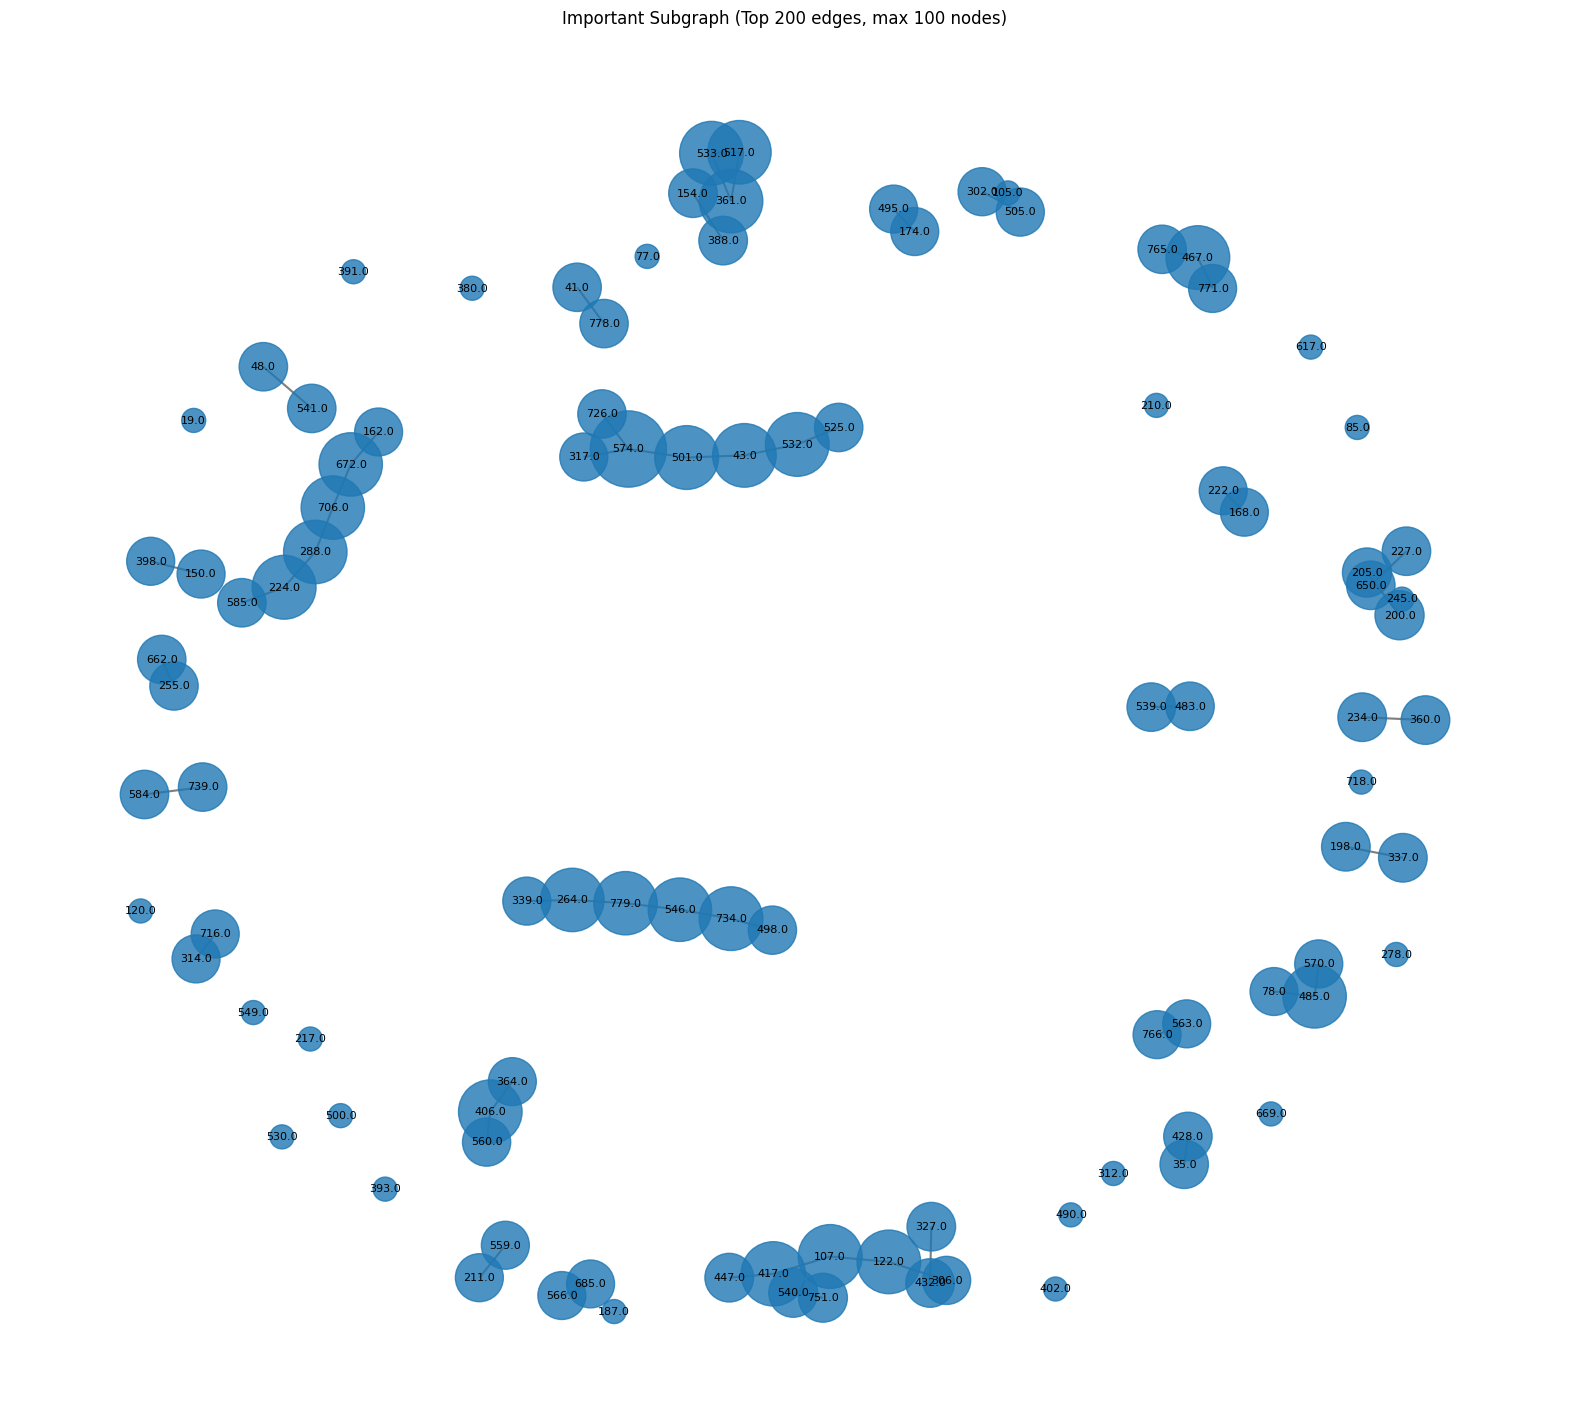

In [2]:
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
TOP_K_EDGES = 200        # control number of important edges
MAX_NODES = 100           # limit number of nodes displayed

# ----------------------------
# LOAD DATA
# ----------------------------
with open("../grenade_original/Contrastive_Learning_Approach/adjacency_matrices/adjacency_final__exp5__ntrials_1.pkl", "rb") as f:
    adj_matrix = pickle.load(f)

with open("../grenade_original/Contrastive_Learning_Approach/embeddings/embeddings__exp5__ntrials_1.npy", "rb") as f:
    embeddings = np.load(f) # Changed from pickle.load(f) to np.load(f)

edge_df = pd.read_csv("edge_importance_exp5.csv")

# Expected columns:
# source, target, importance_score

# ----------------------------
# SELECT MOST IMPORTANT EDGES
# ----------------------------
edge_df = edge_df.sort_values(by="importance_score", ascending=False)
top_edges = edge_df.head(TOP_K_EDGES)

# ----------------------------
# GET IMPORTANT NODES
# ----------------------------
nodes = set(top_edges["source_node"]).union(set(top_edges["target_node"]))

# Limit number of nodes if needed
if len(nodes) > MAX_NODES:
    # Compute node importance as sum of edge importance
    node_importance = {}

    for _, row in top_edges.iterrows():
        node_importance[row["source_node"]] = node_importance.get(row["source_node"], 0) + row["importance_score"]
        node_importance[row["target_node"]] = node_importance.get(row["target_node"], 0) + row["importance_score"]

    # Sort nodes by importance
    sorted_nodes = sorted(node_importance.items(), key=lambda x: x[1], reverse=True)
    nodes = set([n for n, _ in sorted_nodes[:MAX_NODES]])

# ----------------------------
# BUILD GRAPH
# ----------------------------
G = nx.Graph()

# Add nodes
for node in nodes:
    G.add_node(node)

# Add edges (only if both nodes are selected)
for _, row in top_edges.iterrows():
    if row["source_node"] in nodes and row["target_node"] in nodes:
        G.add_edge(
            row["source_node"],
            row["target_node"],
            weight=row["importance_score"]
        )

# ----------------------------
# NODE SIZE (importance-based)
# ----------------------------
node_importance = {node: 0 for node in G.nodes()}

for u, v, data in G.edges(data=True):
    node_importance[u] += data["weight"]
    node_importance[v] += data["weight"]

node_sizes = [300 + 3000 * node_importance[n] for n in G.nodes()]

# ----------------------------
# LAYOUT (use embeddings if possible)
# ----------------------------
try:
    pos = {i: embeddings[i][:2] for i in G.nodes()}
except:
    pos = nx.spring_layout(G, seed=42)

# ----------------------------
# DRAW GRAPH
# ----------------------------
plt.figure(figsize=(20, 18))

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight'] * 5 for u, v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title(f"Important Subgraph (Top {TOP_K_EDGES} edges, max {MAX_NODES} nodes)")
plt.axis("off")
plt.show()

Images sauvegardées : network_visualization.png et network_visualization.pdf


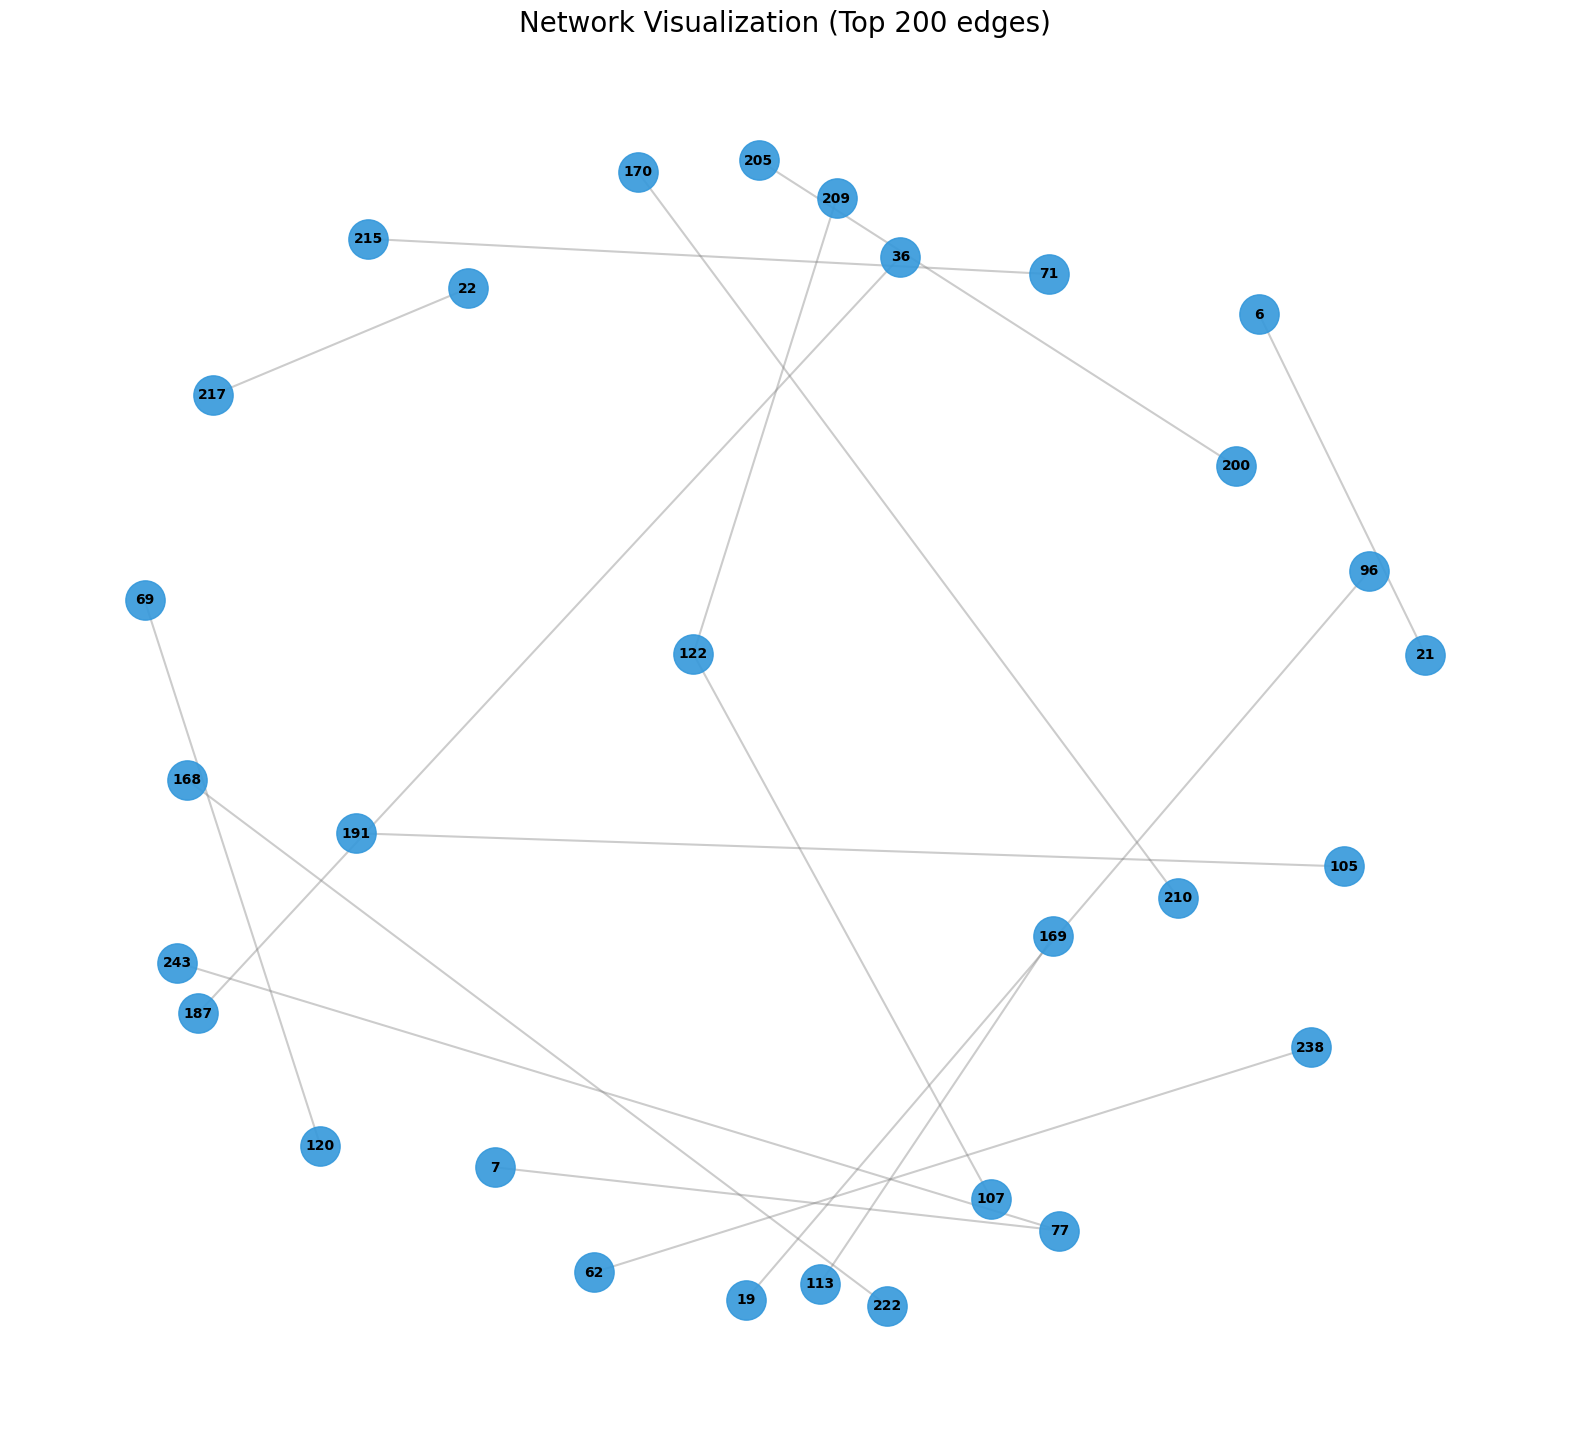

In [3]:
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
TOP_K_EDGES = 200
MAX_NODES = 100
FILENAME = "network_visualization" # Nom du fichier pour l'enregistrement

# ----------------------------
# LOAD DATA
# ----------------------------
edge_df = pd.read_csv("edge_importance_exp5.csv")

# ----------------------------
# SELECT EDGES (Simple selection)
# ----------------------------
# On garde les premières lignes sans se soucier du score pour un graphe "normal"
top_edges = edge_df.head(TOP_K_EDGES)

# ----------------------------
# GET NODES
# ----------------------------
nodes = set(top_edges["source_node"]).union(set(top_edges["target_node"]))
if len(nodes) > MAX_NODES:
    nodes = list(nodes)[:MAX_NODES]

# ----------------------------
# BUILD GRAPH
# ----------------------------
G = nx.Graph()

for _, row in top_edges.iterrows():
    if row["source_node"] in nodes and row["target_node"] in nodes:
        G.add_edge(int(row["source_node"]), int(row["target_node"]))

# ----------------------------
# LAYOUT (Espacement amélioré)
# ----------------------------
# k: augmentez cette valeur pour écarter les nœuds (défaut approx 1/sqrt(n))
# iterations: plus il y en a, plus le layout est stable
pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)

# ----------------------------
# DRAW GRAPH
# ----------------------------
plt.figure(figsize=(20, 18))

# Dessin des nœuds (Taille uniforme)
nx.draw_networkx_nodes(
    G, pos,
    node_size=800,
    node_color='#3498db',
    alpha=0.9
)

# Dessin des arêtes (Largeur uniforme)
nx.draw_networkx_edges(
    G, pos,
    width=1.5,
    edge_color='gray',
    alpha=0.4
)

# Dessin des labels
nx.draw_networkx_labels(
    G, pos,
    font_size=10,
    font_family='sans-serif',
    font_weight='bold'
)

plt.title(f"Network Visualization (Top {TOP_K_EDGES} edges)", fontsize=20)
plt.axis("off")

# ----------------------------
# SAVE AND SHOW
# ----------------------------
# Enregistrement en haute résolution
plt.savefig(f"{FILENAME}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{FILENAME}.pdf", bbox_inches='tight')

print(f"Images sauvegardées : {FILENAME}.png et {FILENAME}.pdf")

plt.show()

/var/folders/_l/lhydzllj5qq6vkb7n2t2grp00000gn/T/ipykernel_20903/2299712027.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_comms)


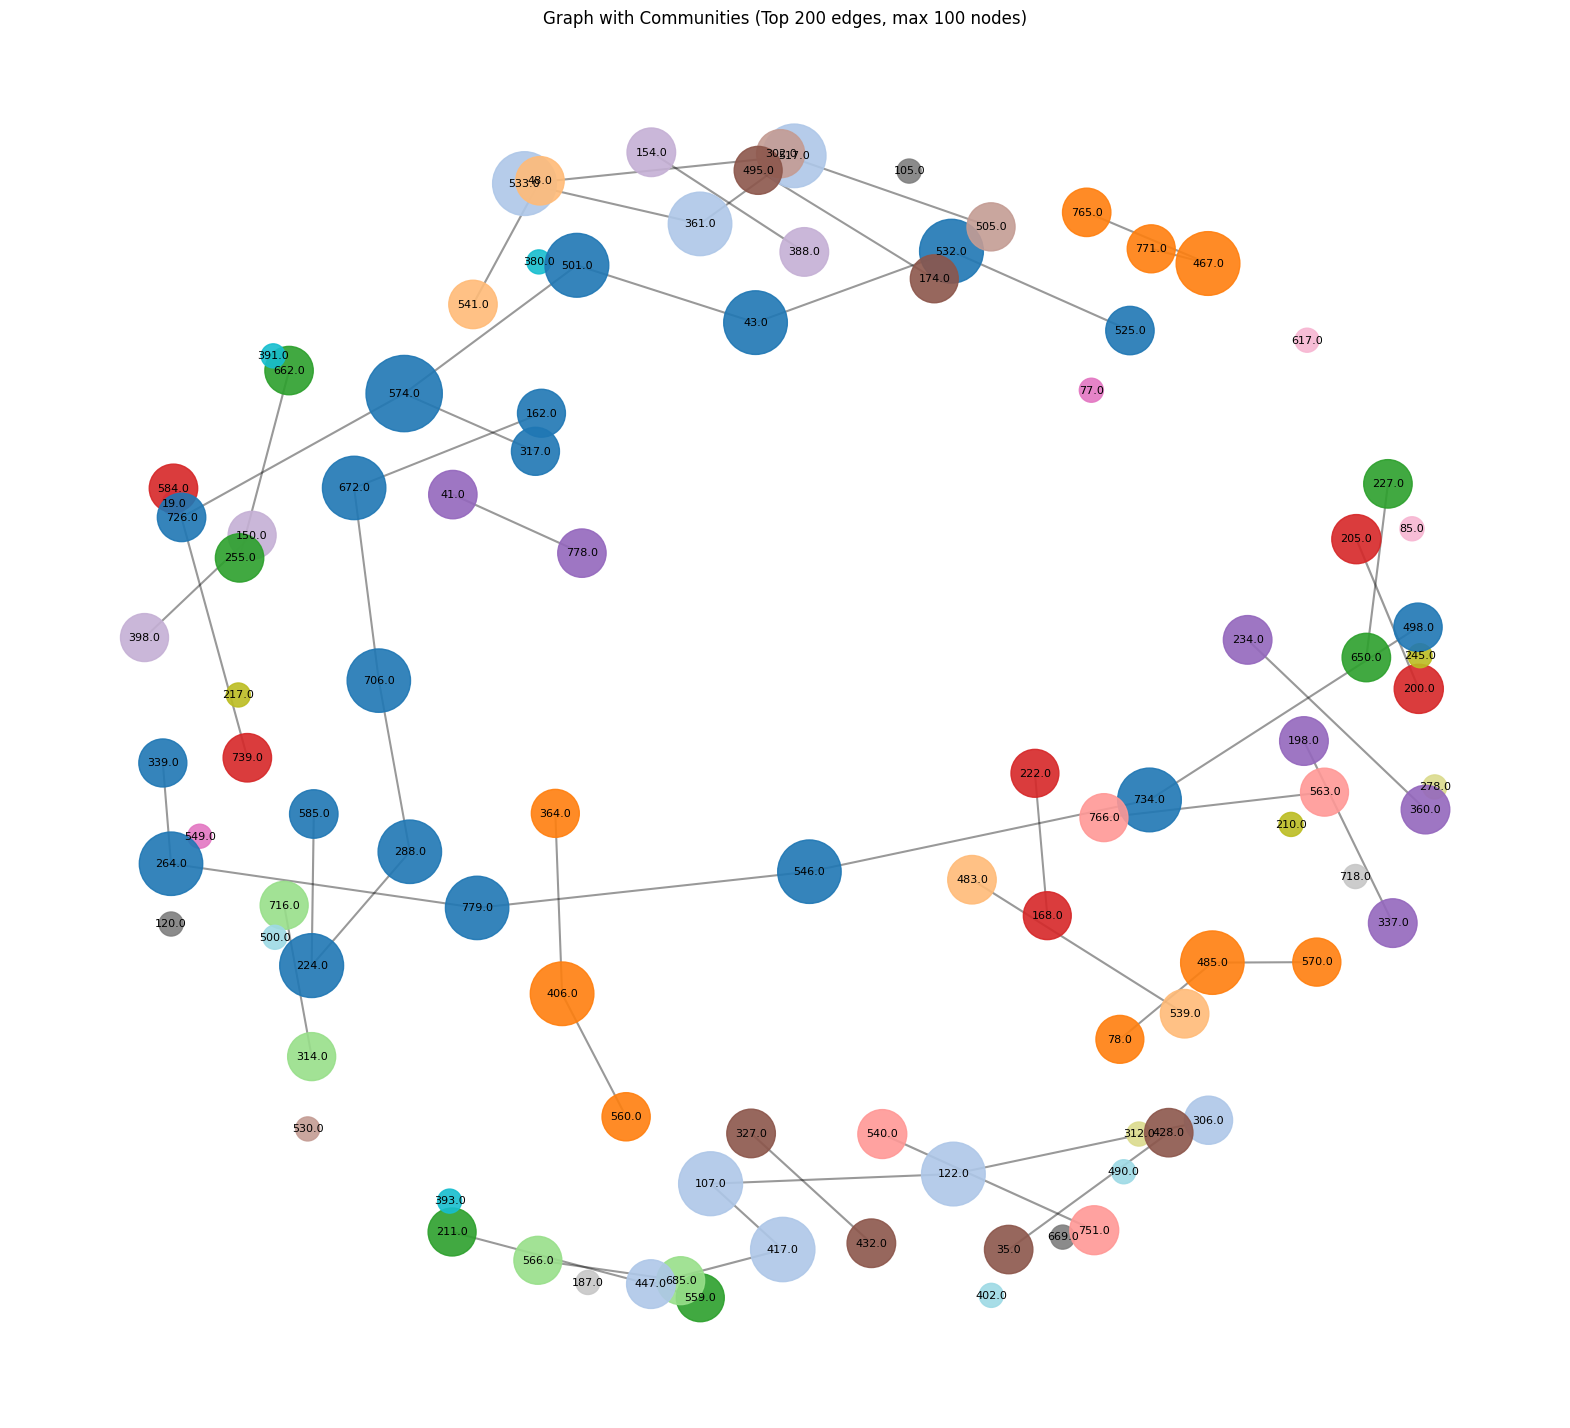


Detected 51 communities:

Community 0: 7 nodes
Community 1: 6 nodes
Community 2: 6 nodes
Community 3: 5 nodes
Community 4: 3 nodes
Community 5: 3 nodes
Community 6: 3 nodes
Community 7: 3 nodes
Community 8: 2 nodes
Community 9: 2 nodes
Community 10: 2 nodes
Community 11: 2 nodes
Community 12: 2 nodes
Community 13: 2 nodes
Community 14: 2 nodes
Community 15: 2 nodes
Community 16: 2 nodes
Community 17: 2 nodes
Community 18: 2 nodes
Community 19: 2 nodes
Community 20: 2 nodes
Community 21: 2 nodes
Community 22: 2 nodes
Community 23: 2 nodes
Community 24: 2 nodes
Community 25: 2 nodes
Community 26: 2 nodes
Community 27: 2 nodes
Community 28: 2 nodes
Community 29: 1 nodes
Community 30: 1 nodes
Community 31: 1 nodes
Community 32: 1 nodes
Community 33: 1 nodes
Community 34: 1 nodes
Community 35: 1 nodes
Community 36: 1 nodes
Community 37: 1 nodes
Community 38: 1 nodes
Community 39: 1 nodes
Community 40: 1 nodes
Community 41: 1 nodes
Community 42: 1 nodes
Community 43: 1 nodes
Community 44: 1

In [4]:
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
TOP_K_EDGES = 200
MAX_NODES = 100

# ----------------------------
# LOAD DATA
# ----------------------------
with open("../grenade_original/Contrastive_Learning_Approach/adjacency_matrices/adjacency_final__exp5__ntrials_1.pkl", "rb") as f:
    adj_matrix = pickle.load(f)

with open("../grenade_original/Contrastive_Learning_Approach/embeddings/embeddings__exp5__ntrials_1.npy", "rb") as f:
    embeddings = np.load(f) # Changed from pickle.load(f) to np.load(f)

edge_df = pd.read_csv("edge_importance_exp5.csv")
# ----------------------------
# SELECT MOST IMPORTANT EDGES
# ----------------------------
edge_df = edge_df.sort_values(by="importance_score", ascending=False)
top_edges = edge_df.head(TOP_K_EDGES)

# ----------------------------
# GET IMPORTANT NODES
# ----------------------------
nodes = set(top_edges["source_node"]).union(set(top_edges["target_node"]))

if len(nodes) > MAX_NODES:
    node_importance = {}

    for _, row in top_edges.iterrows():
        node_importance[row["source_node"]] = node_importance.get(row["source_node"], 0) + row["importance_score"]
        node_importance[row["target_node"]] = node_importance.get(row["target_node"], 0) + row["importance_score"]

    sorted_nodes = sorted(node_importance.items(), key=lambda x: x[1], reverse=True)
    nodes = set([n for n, _ in sorted_nodes[:MAX_NODES]])

# ----------------------------
# BUILD GRAPH
# ----------------------------
G = nx.Graph()

for node in nodes:
    G.add_node(node)

for _, row in top_edges.iterrows():
    if row["source_node"] in nodes and row["target_node"] in nodes:
        G.add_edge(
            row["source_node"],
            row["target_node"],
            weight=row["importance_score"]
        )

# ----------------------------
# NODE SIZE (importance-based)
# ----------------------------
node_importance = {node: 0 for node in G.nodes()}

for u, v, data in G.edges(data=True):
    node_importance[u] += data["weight"]
    node_importance[v] += data["weight"]

node_sizes = [300 + 3000 * node_importance[n] for n in G.nodes()]

# ----------------------------
# COMMUNITY DETECTION
# ----------------------------
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

# Map node -> community id
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

# ----------------------------
# COLOR ASSIGNMENT
# ----------------------------
num_comms = len(communities)
cmap = plt.cm.get_cmap("tab20", num_comms)

node_colors = [cmap(node_to_community[n]) for n in G.nodes()]

# ----------------------------
# LAYOUT
# ----------------------------
try:
    pos = {i: embeddings[i][:2] for i in G.nodes()}
except:
    pos = nx.spring_layout(G, seed=42, k=0.3)

# ----------------------------
# DRAW GRAPH
# ----------------------------
plt.figure(figsize=(20, 18))

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight'] * 5 for u, v in G.edges()],
    alpha=0.4
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title(f"Graph with Communities (Top {TOP_K_EDGES} edges, max {MAX_NODES} nodes)")
plt.axis("off")
plt.show()

# ----------------------------
# PRINT COMMUNITY INFO
# ----------------------------
print(f"\nDetected {num_comms} communities:\n")
for i, comm in enumerate(communities):
    print(f"Community {i}: {len(comm)} nodes")

In [5]:
from collections import defaultdict
import numpy as np

community_features = []

for i, comm in enumerate(communities):
    comm_nodes = list(comm)
    subG = G.subgraph(comm_nodes)

    # ----------------------------
    # STRUCTURAL FEATURES
    # ----------------------------
    size = len(comm_nodes)
    num_edges = subG.number_of_edges()
    density = nx.density(subG)

    degrees = [deg for _, deg in subG.degree()]
    avg_degree = np.mean(degrees)

    # centrality
    centrality = nx.degree_centrality(subG)
    top_node = max(centrality, key=centrality.get)

    # ----------------------------
    # EDGE IMPORTANCE
    # ----------------------------
    edge_weights = [d["weight"] for _, _, d in subG.edges(data=True)]
    avg_edge_weight = np.mean(edge_weights) if edge_weights else 0

    # ----------------------------
    # EMBEDDING FEATURES
    # ----------------------------
    comm_embeddings = np.array([embeddings[int(n)] for n in comm_nodes])

    centroid = np.mean(comm_embeddings, axis=0)
    variance = np.mean(np.linalg.norm(comm_embeddings - centroid, axis=1))

    # ----------------------------
    # STORE RESULTS
    # ----------------------------
    community_features.append({
        "community_id": i,
        "size": size,
        "edges": num_edges,
        "density": density,
        "avg_degree": avg_degree,
        "avg_edge_importance": avg_edge_weight,
        "central_node": top_node,
        "embedding_variance": variance
    })

# Convert to DataFrame
features_df = pd.DataFrame(community_features)

print(features_df)

    community_id  size  edges   density  avg_degree  avg_edge_importance  \
0              0     7      6  0.285714    1.714286             0.301587   
1              1     6      5  0.333333    1.666667             0.299068   
2              2     6      5  0.333333    1.666667             0.298686   
3              3     5      4  0.400000    1.600000             0.303827   
4              4     3      3  1.000000    2.000000             0.299587   
5              5     3      2  0.666667    1.333333             0.299357   
6              6     3      2  0.666667    1.333333             0.297522   
7              7     3      2  0.666667    1.333333             0.300863   
8              8     2      1  1.000000    1.000000             0.306182   
9              9     2      1  1.000000    1.000000             0.304948   
10            10     2      1  1.000000    1.000000             0.297781   
11            11     2      1  1.000000    1.000000             0.305637   
12          

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
# 🔁 Chemin à adapter si besoin
FILE_PATH = "analysis_results/top_100_edges_with_context.csv"

df = pd.read_csv(FILE_PATH)

# Nettoyage
df = df.dropna(subset=["source_node", "target_node", "importance_score"])

print(f"Dataset loaded: {len(df)} edges")
df.head()

Dataset loaded: 9530 edges


,rank,importance_score,source_node,target_node,source_label,target_label,source_in_group,source_out_group,target_in_group,target_out_group,source_text,target_text
0,1,0.308186,16,897,gender/sexuality,irrelevant,None/Unclear,None/Unclear,Other,Other,"en fait quant t’es un homme, il faudrait que t...",in memoriam. comment te dire adieu. le premier...
1,2,0.306904,824,403,nation,irrelevant,Other,None/Unclear,Scientists/Academics,Media/Journalists,"c'est le choix des calédoniens, quelle que soi...",je serai demain samedi 16 mars à 9h30 l’invité...
2,3,0.306103,87,519,nation,irrelevant,None/Unclear,None/Unclear,LGBTIQ+,Media/Journalists,"au panama, des étudiants en colère expulsent l...",le premier épisode de notre émission de témoig...
3,4,0.305695,200,224,nation,nation,Politicians/Government,Other Country,None/Unclear,Right,nordstream : le ministre polonais des affaires...,"face à la gravité des enjeux, marion maréchal ..."
4,5,0.304844,461,304,irrelevant,nation,NaN,NaN,Nation/Own Country,NaN,":studio_microphone:à 17h30, rediffusion d'""his...",je crois à l’espérance pour la france .


In [8]:
# Trier par importance
df = df.sort_values(by="importance_score", ascending=False)

# 🔥 PARAMÈTRES (à ajuster selon ton dataset)
TOP_EDGES = 300
MAX_NODES = 100

# 1. garder top edges
df = df.head(TOP_EDGES)

# 2. calcul importance des noeuds
node_importance = {}

for _, row in df.iterrows():
    node_importance[row["source_node"]] = node_importance.get(row["source_node"], 0) + row["importance_score"]
    node_importance[row["target_node"]] = node_importance.get(row["target_node"], 0) + row["importance_score"]

# 3. garder top nodes
top_nodes = sorted(node_importance, key=node_importance.get, reverse=True)[:MAX_NODES]

# 4. filtrer edges cohérents
df = df[
    df["source_node"].isin(top_nodes) &
    df["target_node"].isin(top_nodes)
]

print(f"Edges kept: {len(df)}")
print(f"Nodes kept: {len(top_nodes)}")

Edges kept: 43
Nodes kept: 100


In [9]:
G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(
        int(row["source_node"]),
        int(row["target_node"]),
        weight=row["importance_score"]
    )

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 68 nodes, 40 edges


In [10]:
node_labels = {}
node_groups = {}

for _, row in df.iterrows():
    node_labels[row["source_node"]] = str(row["source_text"])[:40]
    node_labels[row["target_node"]] = str(row["target_text"])[:40]

    node_groups[row["source_node"]] = row.get("source_label", "unknown")
    node_groups[row["target_node"]] = row.get("target_label", "unknown")

In [11]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

print(f"Detected {len(communities)} communities")

Detected 28 communities


In [12]:
cmap = plt.cm.get_cmap("tab20", len(communities))
node_colors = [cmap(node_to_comm[n]) for n in G.nodes()]

/var/folders/_l/lhydzllj5qq6vkb7n2t2grp00000gn/T/ipykernel_20903/744301779.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(communities))


In [13]:
node_importance = {n: 0 for n in G.nodes()}

for u, v, d in G.edges(data=True):
    node_importance[u] += d["weight"]
    node_importance[v] += d["weight"]

node_sizes = [300 + 2000 * node_importance[n] for n in G.nodes()]

In [14]:
pos = nx.spring_layout(G, seed=42, k=0.3)

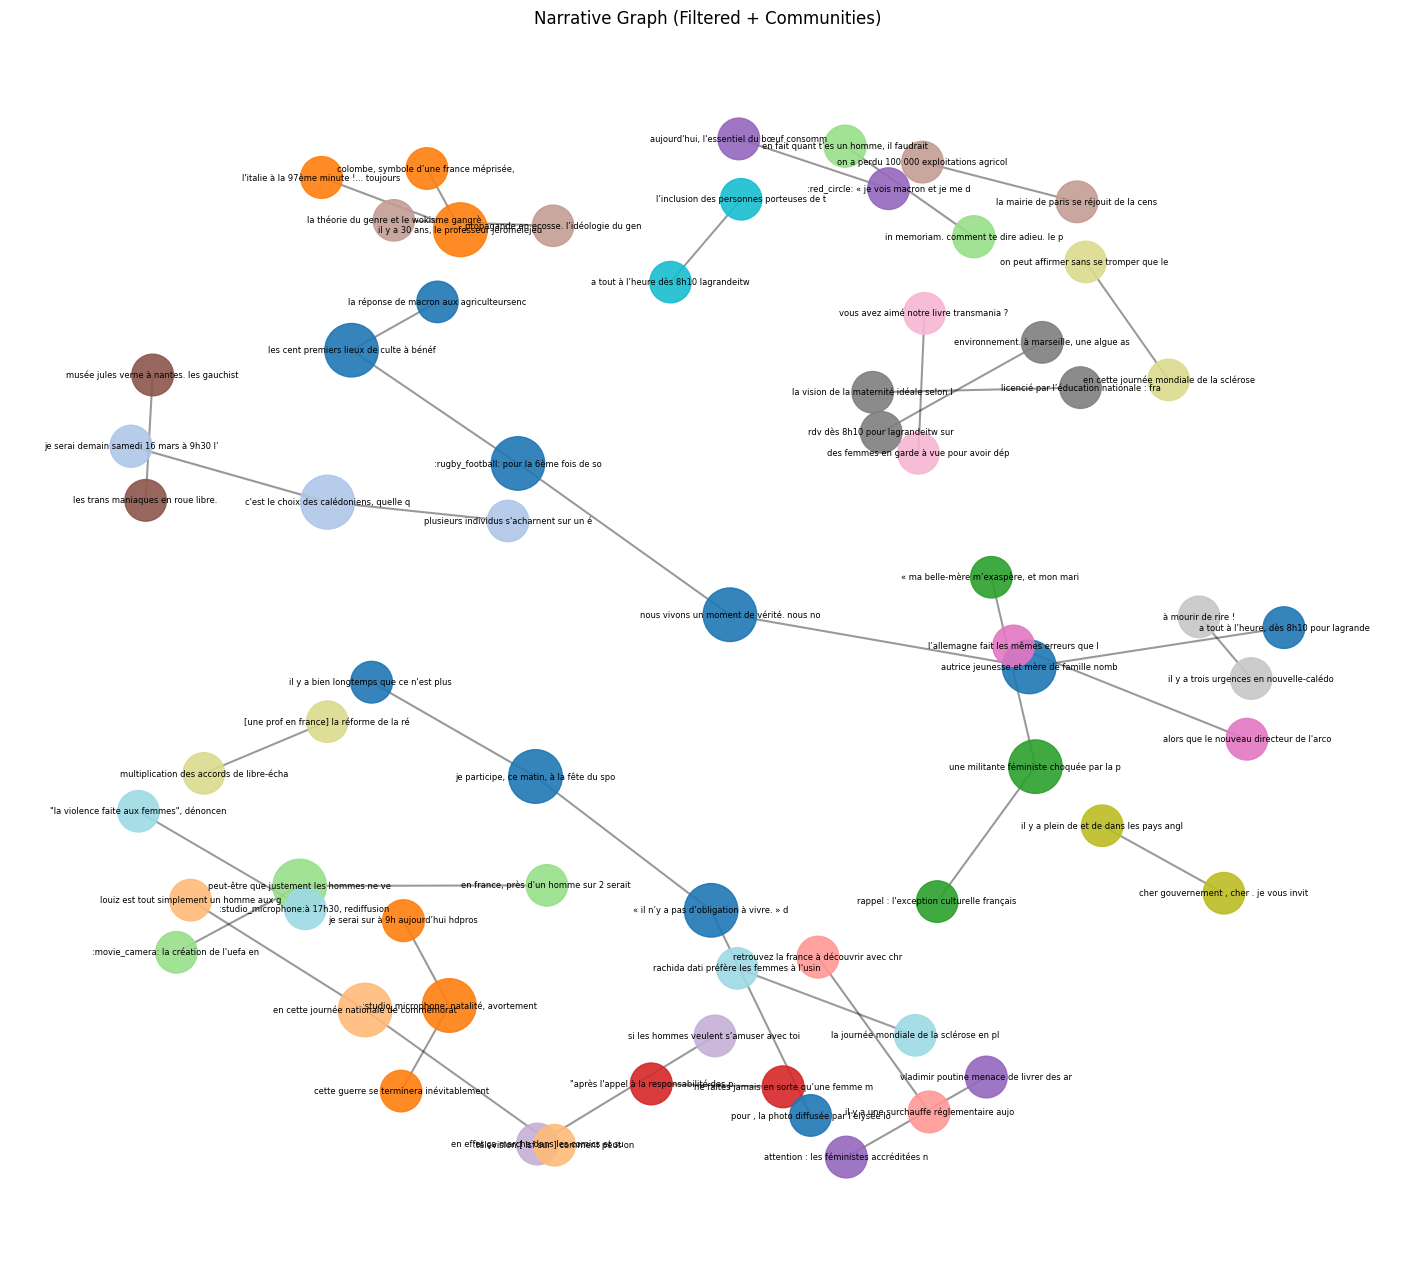

In [15]:
plt.figure(figsize=(18, 16))

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=[d["weight"] * 5 for _, _, d in G.edges(data=True)],
    alpha=0.4
)

# ⚠️ Désactiver si trop chargé
nx.draw_networkx_labels(
    G, pos,
    labels=node_labels,
    font_size=6
)

plt.title("Narrative Graph (Filtered + Communities)")
plt.axis("off")
plt.show()

Edges kept: 43, Nodes kept: 100
Detected 28 communities


/var/folders/_l/lhydzllj5qq6vkb7n2t2grp00000gn/T/ipykernel_20903/4092739866.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(communities))


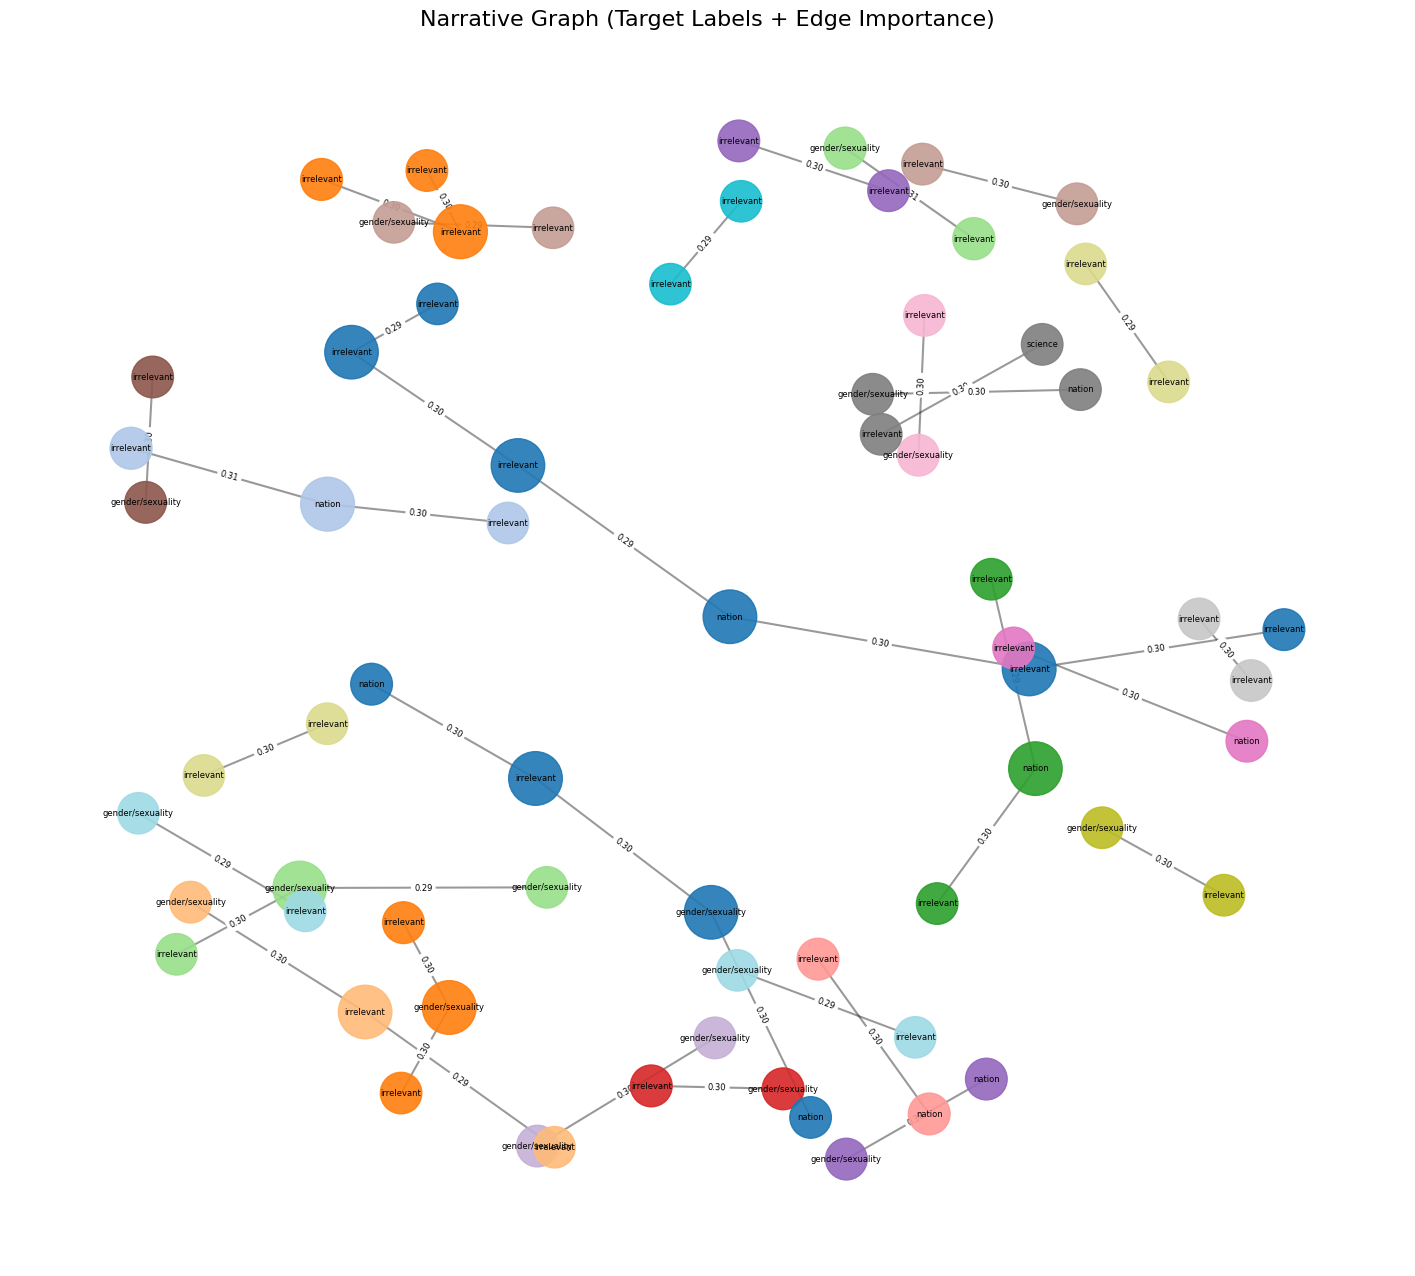

Graph exported to analysis_results/filtered_graph.gexf


In [16]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# ----------------------------
# PARAMETERS
# ----------------------------
FILE_PATH = "analysis_results/top_100_edges_with_context.csv"  # à adapter
TOP_EDGES = 300   # nombre maximum d'arêtes importantes à garder
MAX_NODES = 100   # nombre maximum de nœuds à afficher
EDGE_LABEL_THRESHOLD = 0.0  # seuil pour afficher le poids sur les arêtes

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=["source_node", "target_node", "importance_score"])

# ----------------------------
# FILTER TOP EDGES AND NODES
# ----------------------------
df = df.sort_values(by="importance_score", ascending=False).head(TOP_EDGES)

node_importance = {}
for _, row in df.iterrows():
    node_importance[row["source_node"]] = node_importance.get(row["source_node"], 0) + row["importance_score"]
    node_importance[row["target_node"]] = node_importance.get(row["target_node"], 0) + row["importance_score"]

top_nodes = sorted(node_importance, key=node_importance.get, reverse=True)[:MAX_NODES]
df = df[df["source_node"].isin(top_nodes) & df["target_node"].isin(top_nodes)]

print(f"Edges kept: {len(df)}, Nodes kept: {len(top_nodes)}")

# ----------------------------
# BUILD GRAPH
# ----------------------------
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(int(row["source_node"]), int(row["target_node"]), weight=row["importance_score"])

# NODE LABELS = source_label + target_label
# ----------------------------
node_labels = {}

for _, row in df.iterrows():
    # source node label
    node_labels[row["source_node"]] = str(row.get("source_label", "N/A"))
    # target node label
    node_labels[row["target_node"]] = str(row.get("target_label", "N/A"))
# ----------------------------
# COMMUNITY DETECTION
# ----------------------------
communities = list(greedy_modularity_communities(G))
node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i
print(f"Detected {len(communities)} communities")

# ----------------------------
# NODE COLOR AND SIZE
# ----------------------------
cmap = plt.cm.get_cmap("tab20", len(communities))
node_colors = [cmap(node_to_comm[n]) for n in G.nodes()]

node_sizes = [300 + 2000 * sum(d["weight"] for u,v,d in G.edges(data=True) if u==n or v==n) for n in G.nodes()]

# ----------------------------
# POSITION (LAYOUT)
# ----------------------------
pos = nx.spring_layout(G, seed=42, k=0.3)

# ----------------------------
# EDGE LABELS = IMPORTANCE_SCORE
# ----------------------------
edge_labels = {(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True) if d['weight'] > EDGE_LABEL_THRESHOLD}

# ----------------------------
# DRAW GRAPH
# ----------------------------
plt.figure(figsize=(18,16))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=[d["weight"]*5 for _,_,d in G.edges(data=True)], alpha=0.4)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=6)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title("Narrative Graph (Target Labels + Edge Importance)", fontsize=16)
plt.axis("off")

# --- AJOUT ICI ---
# Sauvegarde en PNG (haute résolution)
plt.savefig("mon_graphique.png", dpi=300, bbox_inches='tight')
# Sauvegarde en PDF (format vectoriel, idéal pour zoomer sans perte)
plt.savefig("mon_graphique.pdf", bbox_inches='tight')
plt.show()

# ----------------------------
# EXPORT GEXF FOR GEPHI
# ----------------------------
nx.write_gexf(G, "filtered_graph.gexf")
print("Graph exported to analysis_results/filtered_graph.gexf")

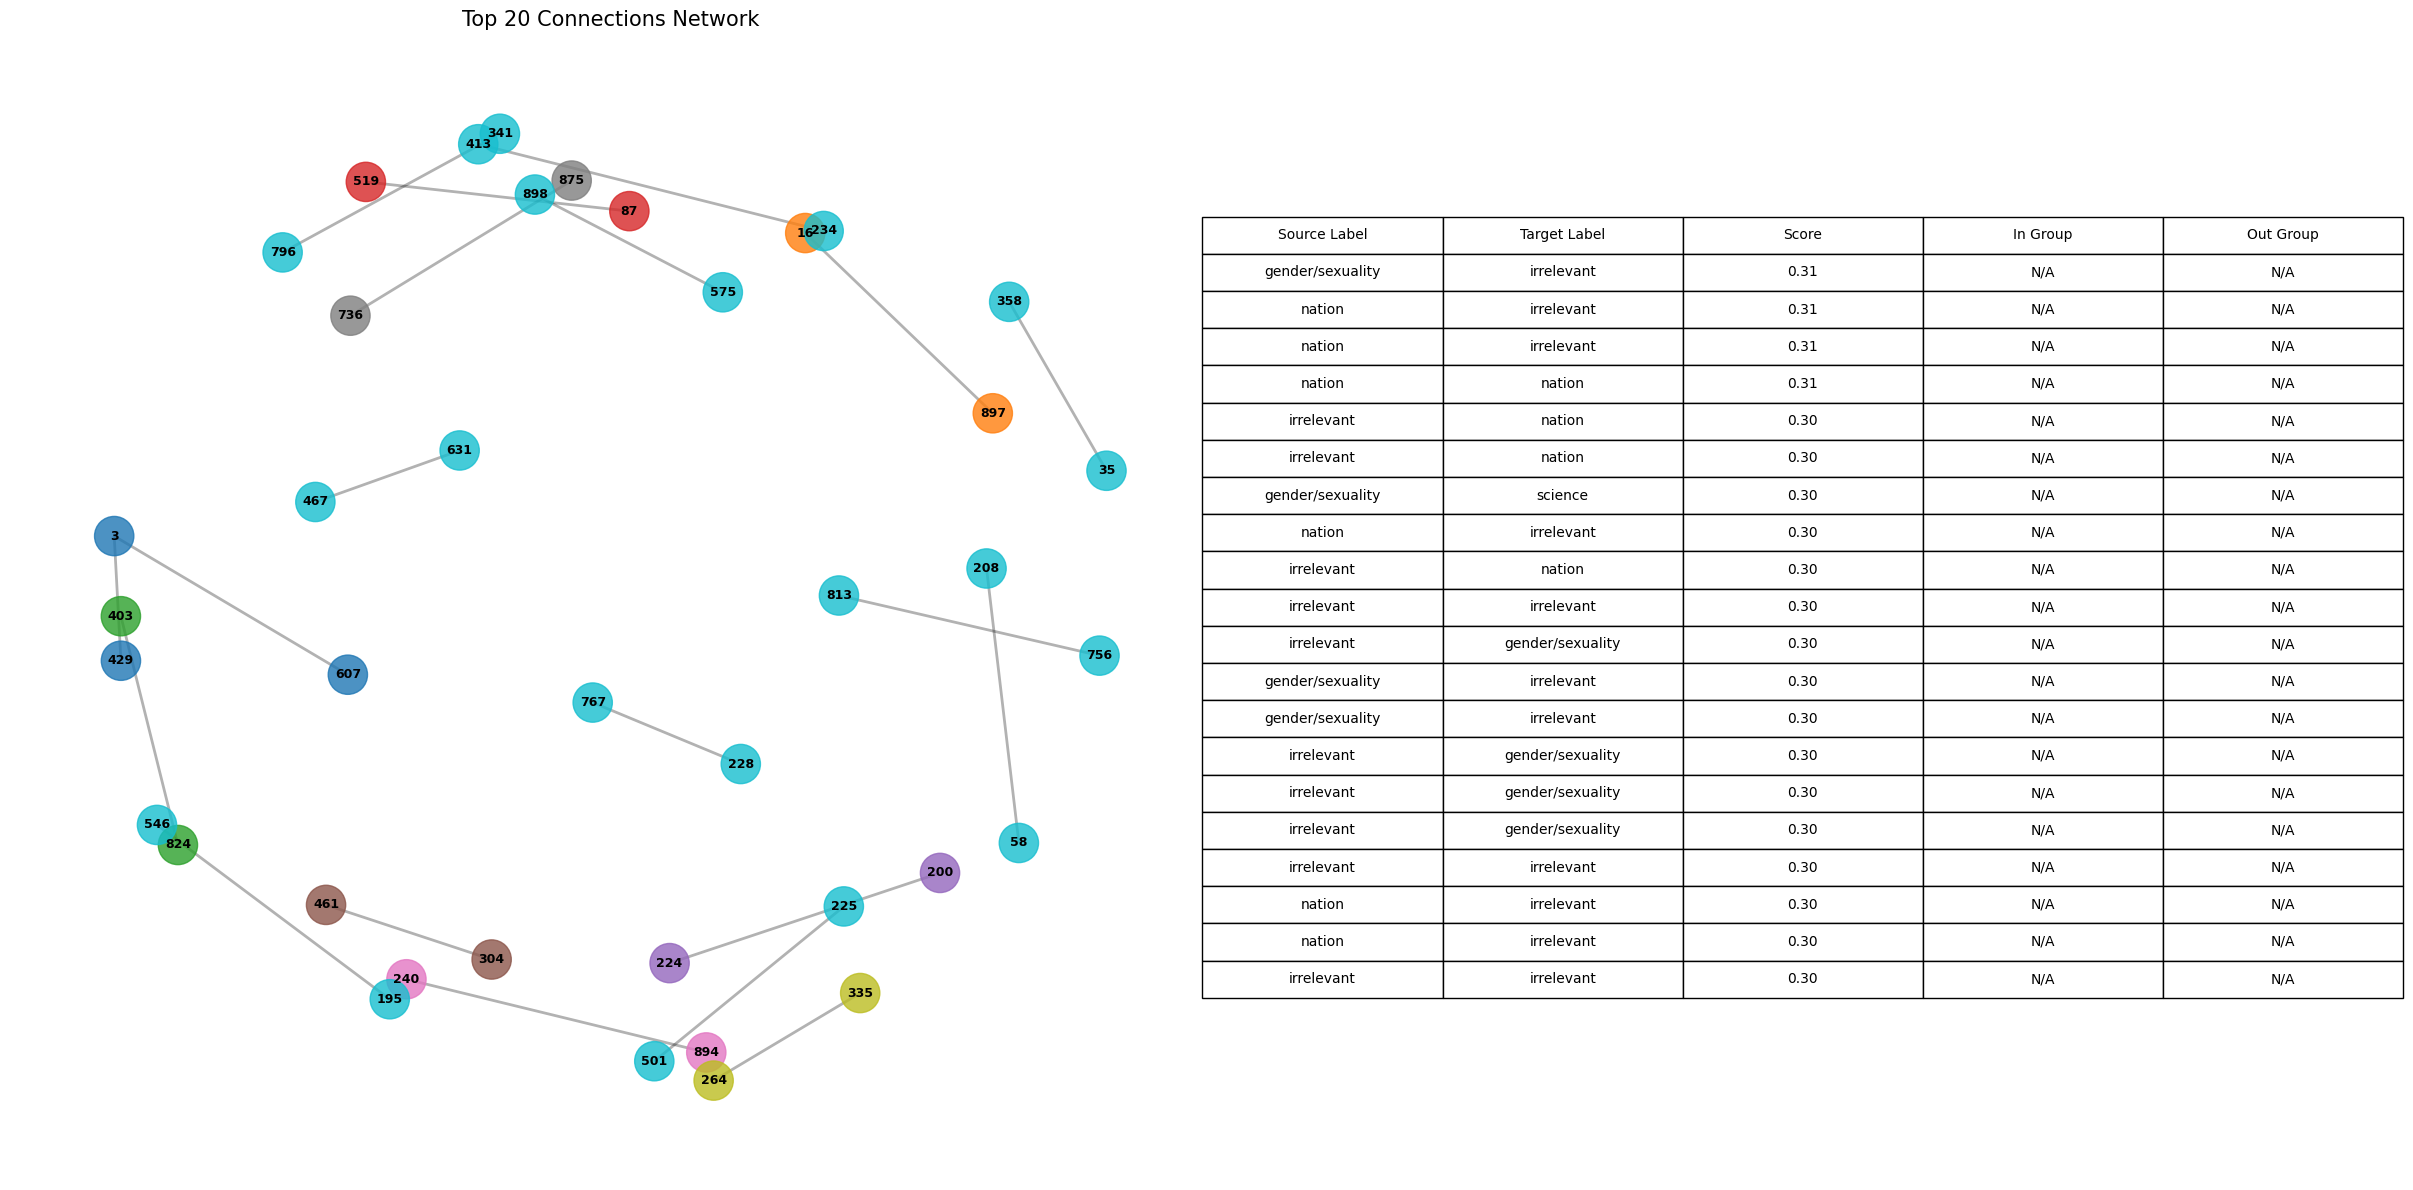

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# --- PARAMÈTRES ---
FILE_PATH = "analysis_results/top_100_edges_with_context.csv"
TOP_EDGES = 20  # On réduit pour que le tableau soit lisible
# ------------------

df = pd.read_csv(FILE_PATH)
df = df.sort_values(by="importance_score", ascending=False).head(TOP_EDGES)

# Création du Graphe
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["source_node"], row["target_node"], weight=row["importance_score"])

# Détection de communautés (Groupes)
communities = list(greedy_modularity_communities(G))
node_to_comm = {node: i for i, comm in enumerate(communities) for node in comm}

# --- PRÉPARATION DE LA FIGURE (Subplots) ---
fig, (ax_graph, ax_table) = plt.subplots(1, 2, figsize=(24, 12), gridspec_kw={'width_ratios': [1.2, 1]})

# 1. DESSIN DU GRAPHE (Côté Gauche)
pos = nx.spring_layout(G, k=0.5, seed=42)
node_colors = [plt.cm.tab10(node_to_comm[n]) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax_graph, node_color=node_colors, node_size=800, alpha=0.8)
nx.draw_networkx_edges(G, pos, ax=ax_graph, width=2, alpha=0.3)
nx.draw_networkx_labels(G, pos, ax=ax_graph, font_size=9, font_weight='bold')

ax_graph.set_title(f"Top {TOP_EDGES} Connections Network", fontsize=15)
ax_graph.axis("off")

# 2. CRÉATION DU TABLEAU (Côté Droite)
# On prépare les données textuelles
table_data = []
for _, row in df.iterrows():
    table_data.append([
        row.get('source_label', 'N/A'),
        row.get('target_label', 'N/A'),
        f"{row['importance_score']:.2f}",
        row.get('in_group', 'N/A'),  # Assurez-vous que ces colonnes existent
        row.get('out_group', 'N/A')
    ])

columns = ["Source Label", "Target Label", "Score", "In Group", "Out Group"]

# Affichage du tableau
ax_table.axis('tight')
ax_table.axis('off')
table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8) # Ajuste la hauteur des lignes

plt.tight_layout()
plt.savefig("graph_dashboard.png", dpi=300)
plt.show()